In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_radius_of_gyration)=
# Get radius of gyration

*Computing the radius of gyration of a molecular system.*

The function {func}`molsysmt.structure.get_radius_of_gyration` measures the spatial distribution of atoms around their center of mass or geometric center, quantifying overall macromolecular compactness and shape fluctuations.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_radius_of_gyration`.
:::


## Basic usage

Let's show how to calculate the geometric radius of gyration over a pentalanine trajectory:


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import pyunitwizard as puw


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We calculate the geometric radius of gyration over all heavy atoms using {func}`molsysmt.structure.get_radius_of_gyration`:


In [4]:
rg_geom = msm.structure.get_radius_of_gyration(molsys, selection='atom_type!="H"')


In [5]:
print('Radius of gyration shape:', rg_geom.shape)
print(f'Mean geometric Rg: {rg_geom.mean():.3f}')


Radius of gyration shape: (5000,)
Mean geometric Rg: 0.515 nanometer


## Mass-weighted radius of gyration

Passing `weights='masses'` calculates the physical, mass-weighted radius of gyration around the center of mass:


In [6]:
rg_mass = msm.structure.get_radius_of_gyration(molsys, selection='atom_type!="H"', weights='masses')
print(f'Mean mass-weighted Rg: {rg_mass.mean():.3f}')


Mean mass-weighted Rg: 0.514 nanometer


## Plotting radius of gyration trajectory

We plot the time series and distribution of the radius of gyration to observe conformational transitions between compact and extended states:


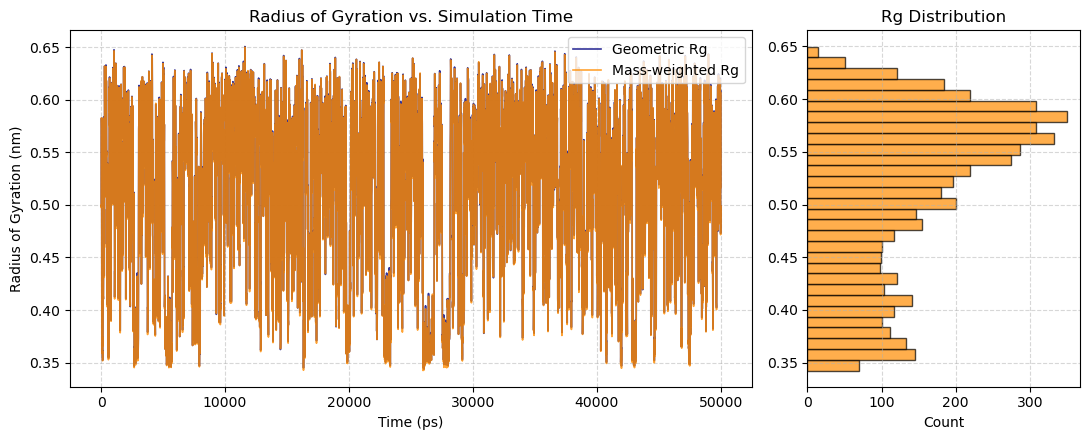

In [7]:
time = msm.get(molsys, element='system', time=True)
time_val = puw.get_value(time, to_unit='ps')
rg_geom_val = puw.get_value(rg_geom, to_unit='nm')
rg_mass_val = puw.get_value(rg_mass, to_unit='nm')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [2.5, 1]})

# Time series
ax1.plot(time_val, rg_geom_val, label='Geometric Rg', color='navy', lw=1.2, alpha=0.8)
ax1.plot(time_val, rg_mass_val, label='Mass-weighted Rg', color='darkorange', lw=1.2, alpha=0.8)
ax1.set_xlabel('Time (ps)')
ax1.set_ylabel('Radius of Gyration (nm)')
ax1.set_title('Radius of Gyration vs. Simulation Time')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Histogram distribution
ax2.hist(rg_mass_val, bins=30, orientation='horizontal', color='darkorange', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Count')
ax2.set_title('Rg Distribution')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query system time and structural attributes with {func}`molsysmt.basic.get`.
- {ref}`Get center <Tutorial_Get_center>`: Compute the geometric center or center of mass with {func}`molsysmt.structure.get_center`.
- {ref}`Get principal axes <Tutorial_Get_principal_axes>`: Compute the principal axes and moments of inertia with {func}`molsysmt.structure.get_principal_axes`.
- {ref}`Get RMSD <Tutorial_Get_rmsd>`: Compute root-mean-square deviations with {func}`molsysmt.structure.get_rmsd`.
:::
